<a href="https://colab.research.google.com/github/hussainsakinah/Neural-Networks-From-Scratch/blob/main/micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

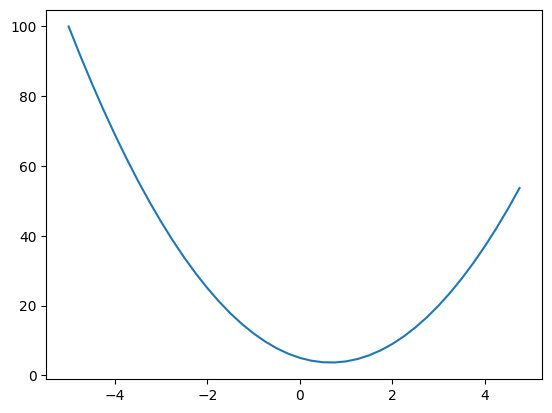

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000001
x = 2/3
(f(x+h) - f(x)) / h

2.999378523327323e-06

In [6]:
#increasing complexity
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
#understanding derivatives

h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [1]:
#implementing a neural net

class Value:
  #The double underscore methods are dunder methods
  # They're hooks that Python calls automatically when you use certain syntax or operators on your objects
  # a + b	implies a.__add__(b)
  # a - b implies a.__sub__(b)
  # a * b implies a.__mul__(b)

  # You can only hook into operators using Python's exact reserved dunder names
  # You can't invent your own dunder name and expect an operator to call it

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    # _backward stores how to chain the outputs gradient into the inputs gradient
    self._backward = lambda: None # By default does nothing
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self): # The repr function lets us print in whatever form we want the data to be printed
    return f"Value(data = {self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other) # This now lets us add other datatypes to the Value datatype objects
    out = Value(self.data + other.data, (self, other),'+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad # If both self and other are the same objects, then this line would mean we are overwrite the same object
    out._backward = _backward

    return out

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  # If you want * to work on your objects, it must be named __mul__, no exceptions.
  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other),'*')
    def _backward():
      self.grad += (other.data) * (out.grad)
      other.grad += (self.data) * (out.grad)
    out._backward = _backward
    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0

    for node in reversed(topo):
      node._backward()

  def __radd__(self, other):
    return self + other

  def __rmul__(self, other):
    return self * other # This is when we multiply other * self

  def __truediv__(self, other):
    return self * (other**-1)

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for ease to define the backprop"
    out = Value(self.data ** other, (self, ), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other-1)) * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    exponential = math.exp(x)
    out = Value(exponential, (self, ), 'exp')

    def _backward():
      self.grad += exponential * out.grad
    out._backward = _backward
    return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c #(a.__mul__(b)).__add__(c)
d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
print(L)

Value(data = -8.0)


In [9]:
d._prev

{Value(data = -6.0), Value(data = 10.0)}

In [10]:
d._op

'+'

In [2]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set() # initializing empty set for both nodes and edges
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular {'record'} node for it
    dot.node(name = uid, label="{ %s | data %.4f | %.4f }" % (n.label, n.data, n.grad), shape = 'record')
    if n._op:
      # if this value is a result of some operation, then create an op node for it
      dot.node(name=uid + n._op, label=n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

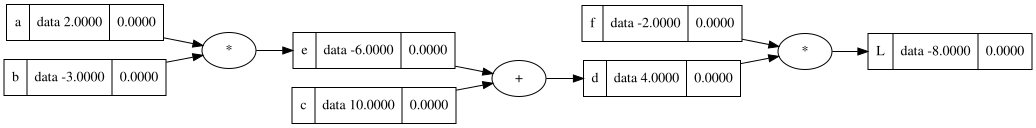

In [12]:
draw_dot(L)

### Manually Backpropagating

In [13]:
L.grad = 1.0

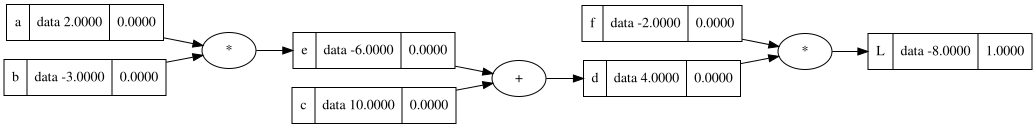

In [14]:
draw_dot(L)

L = d * f

dL/dd = ? = f

(f(x+h)-f(x))/h

((d+h)*f - d*f)/h = f

dL/dd = f

dL/df  = d


---



In [15]:
d.grad = -2.0
f.grad = 4.0

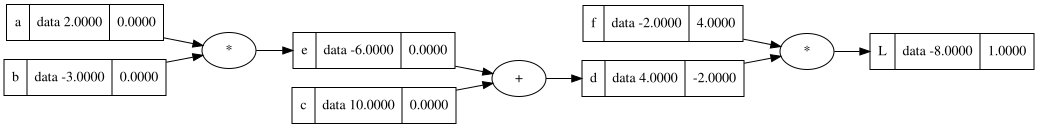

In [16]:
draw_dot(L)



---


dd/dc = 1.0
de/dc = 1.0
d = c + e

**WHAT WE WANT:**

dL/de = (dL/dd) * (dd/de)

dL/dc = (dL/dd) * (dd/dc)

**WHAT WE KNOW:**

dL/dd

dd/de

dd/dc

In [17]:
e.grad = -2.0
c.grad = -2.0

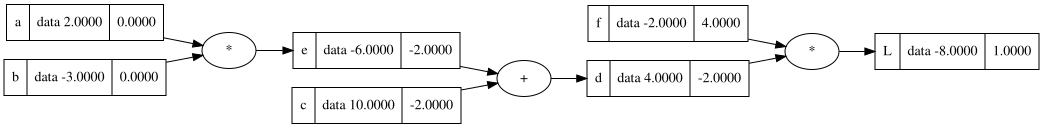

In [18]:
draw_dot(L)

**WHAT WE WANT:**

dL/da = (dL/de) * (de/da)

dL/db = (dL/de) * (de/db)

**WHAT WE KNOW:**

dL/de = -2.0

de/da = b

de/db = a

In [19]:
a.grad = -2.0*-3.0
b.grad = -2.0*2.0

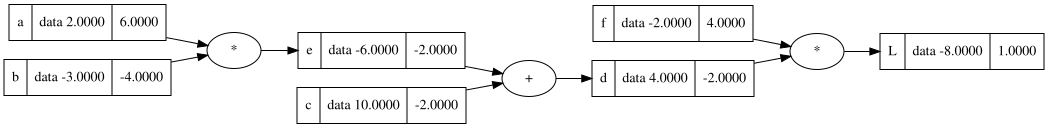

In [20]:
draw_dot(L)

In [21]:
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c #(a.__mul__(b)).__add__(c)
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0 + h, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  # e.data += h
  d = e + c
  # d.data += h
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2 - L1)/h)
lol()

-3.9999999999995595


In [22]:
# nudging the inputs to optimize the loss
# 0.01 is the step
# we multiply the step with the gradient so that we move in the direction of the gradient

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

# we expect the loss to have reduced
print(L.data)

-7.286496


In [23]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'

#### The gradient at any point tells us how that particular input is affecting the total output of the neuron.
#### A positive gradient means the input is having a positive effect on the neuron, meaning the output of the neuron increases. And a negative gradient means the opposite.

In [24]:
o.grad = 1.0

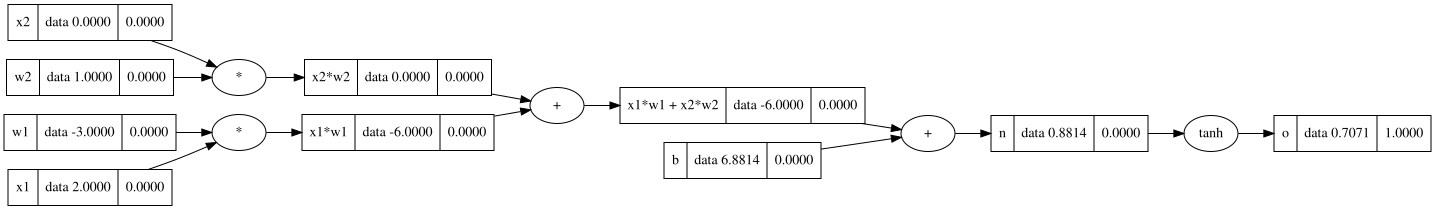

In [25]:
draw_dot(o)

o = tanh(n)

do/dn = 1 - o**2

In [ ]:
n.grad = 1 - o.data**2

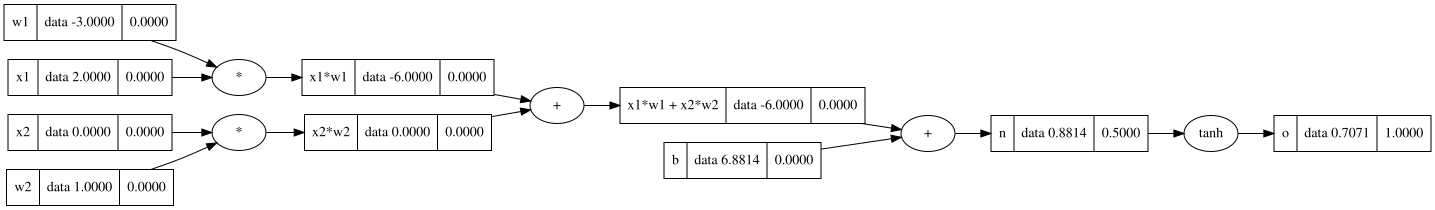

In [ ]:
draw_dot(o)

do/db = do/dn * dn/db = 0.5 * 1 = 0.5

do/d(x1*w1 + x2*w2) = do/dn * dn/(x1*w1 + x2*w2) = 0.5 * 1 = 0.5

In [ ]:
b.grad = 0.5
x1w1x2w2.grad = 0.5

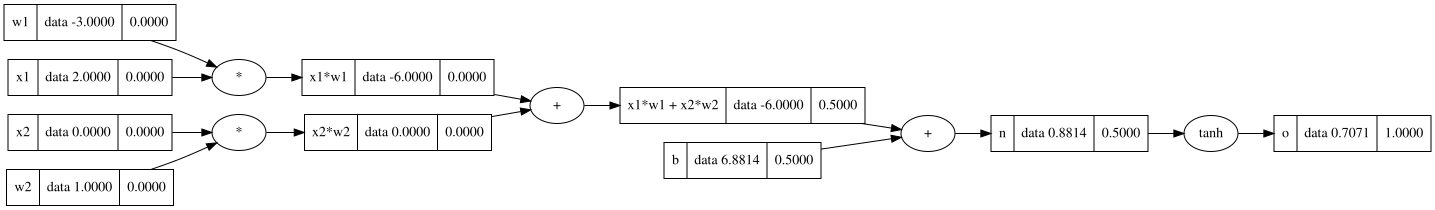

In [ ]:
draw_dot(o)

In [ ]:
x1w1.grad = 0.5
x2w2.grad = 0.5

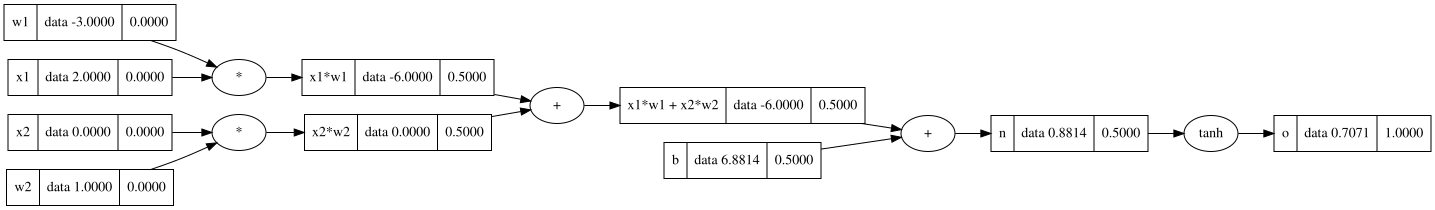

In [ ]:
draw_dot(o)

In [ ]:
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

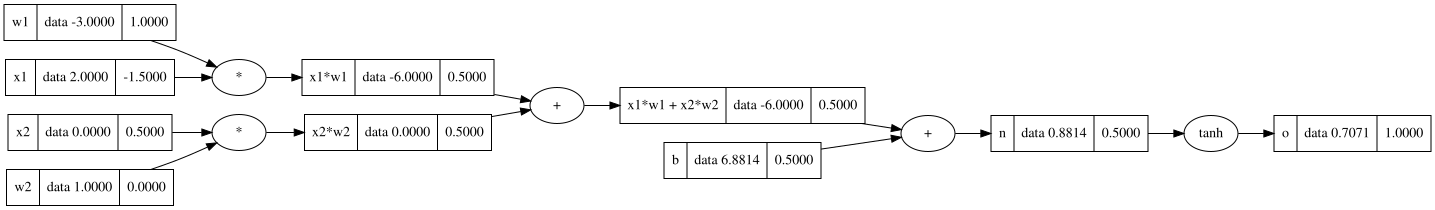

In [ ]:
draw_dot(o)

Go back to the definition of the Value class and modify the __init__ method to have the grad attribute, so that the code calculates the gradient on its own, and we wouldn't have to do it manually.

### Calculating gradient using the _backward method

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'

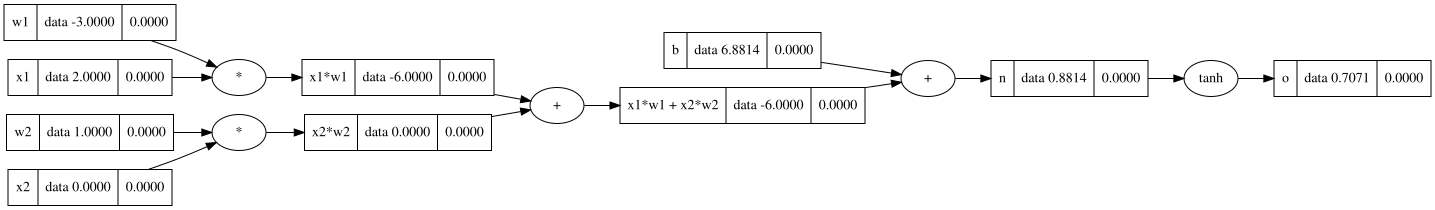

In [ ]:
draw_dot(o)

In [ ]:
# we need to initialize o.grad = 1.0
o.grad = 1.0

In [ ]:
o._backward()

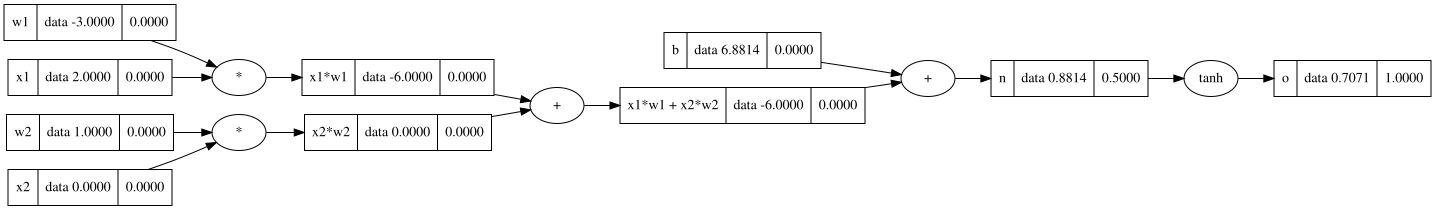

In [ ]:
draw_dot(o)

In [ ]:
n._backward()

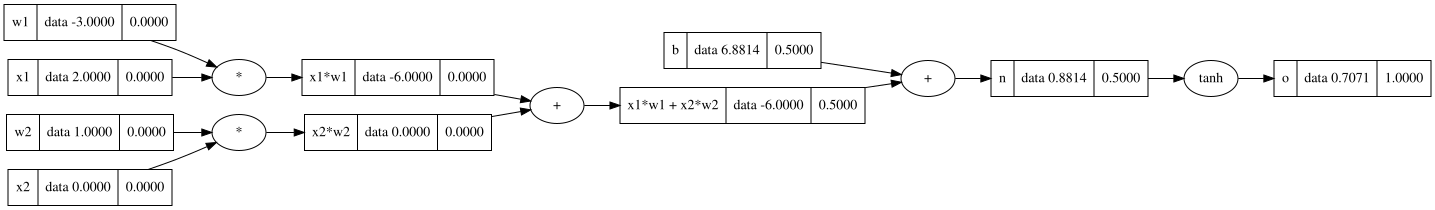

In [ ]:
draw_dot(o)

In [ ]:
b._backward()

In [ ]:
x1w1x2w2._backward()

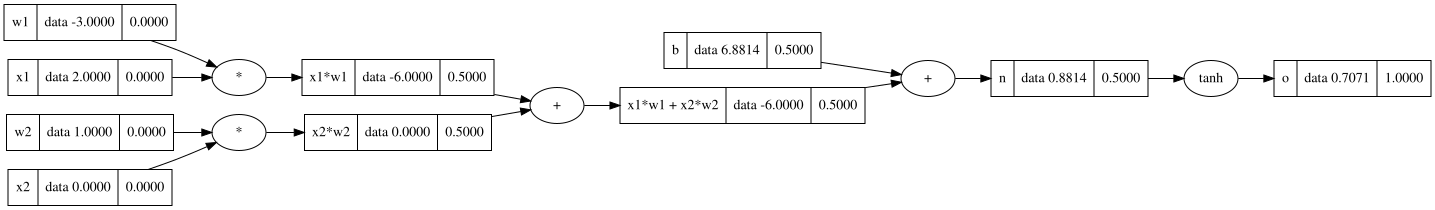

In [ ]:
draw_dot(o)

In [ ]:
x1w1._backward()
x2w2._backward()

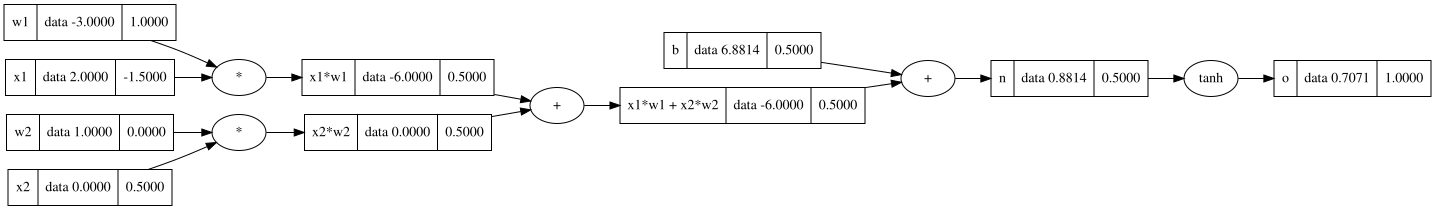

In [ ]:
draw_dot(o)

Running Topological Sort on the DAG such that for every directed edge u → v, vertex u comes before vertex v.

In [ ]:
topo = []
visited = set()

def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(o)
topo

[Value(data = 6.881373587019543),
 Value(data = 1.0),
 Value(data = 0.0),
 Value(data = 0.0),
 Value(data = -3.0),
 Value(data = 2.0),
 Value(data = -6.0),
 Value(data = -6.0),
 Value(data = 0.8813735870195432),
 Value(data = 0.7071067811865476)]

Now run everything again so that you wouldn't have to call the _backward method for every node

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'

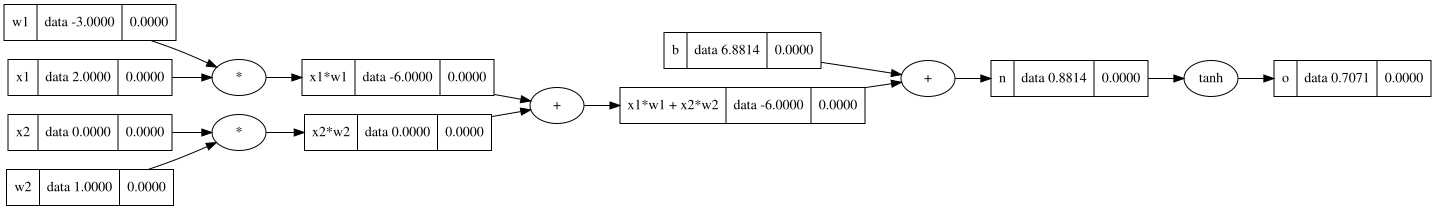

In [ ]:
draw_dot(o)

In [ ]:
topo = []
visited = set()

def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(o)
topo

o.grad = 1.0

for node in reversed(topo):
  node._backward()

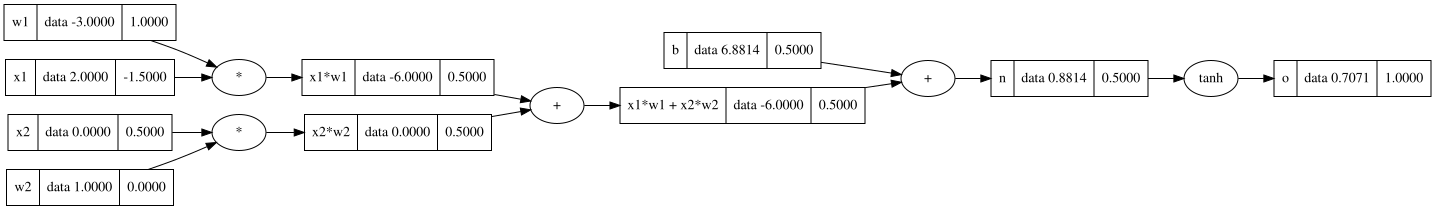

In [ ]:
draw_dot(o)

# Once confirmed this is working, put the topological sort in the block where you define the Value class

Re-run the updated Value class and call the backpropagate function

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'

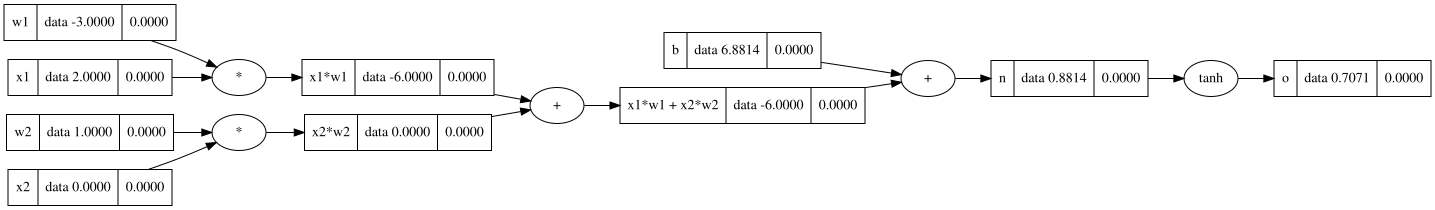

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

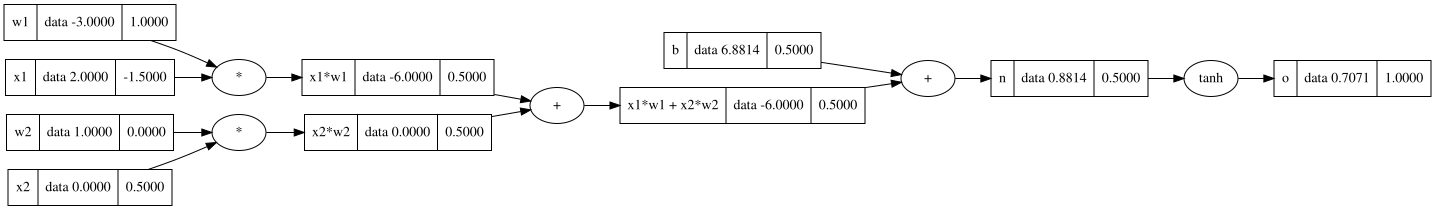

In [ ]:
draw_dot(o)

## Trying special cases

1. Using the same object more than once
    - So far we had used every variable just once, now we'd be using a variable more than just once. According to the way we assigned the value for grad before, it was just assigning a value to the gradient, therefore upon another backpropagation, as in the case of using the same variable more than once, the gradient wasn't accumulating the gradient from the repeated backpropagation, it was instead re-assigning the gradient value to the .grad attribute.
    - To solve this, we are going to change it like this; instead of
    "self.grad = 1.0 * other.data"; we will write it as "self.grad += 1.0 * other.data"; so that the gradient from repeated backpropagations gets accumulated.

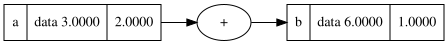

In [ ]:
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

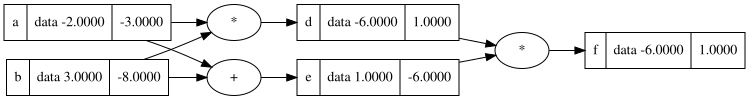

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()

draw_dot(f)

2. The Value class doesn't allow any other operations to be applied with any other datatypes. So we modify the Value class such that the other object is wrapped in the Value class, if it doesn't already belong to the Value class.

In [ ]:
a = Value(2.0)
4 * a

Value(data = 8.0)

Running the code after modifying the Value class for division, subtraction, power operation and exponential function

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# -----
e = (2*n).exp()
o = (e-1) / (e+1)
o.label = 'o'
# -----
# o = n.tanh(); o.label='o'
o.backward()

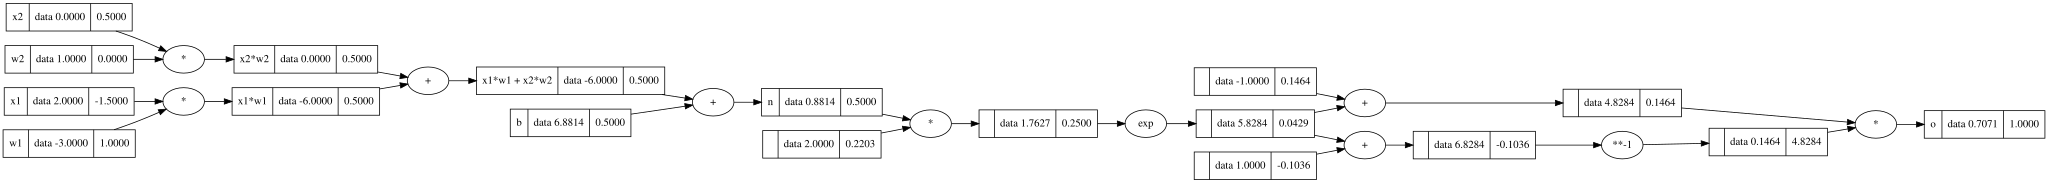

In [ ]:
draw_dot(o)

# Implementing everything using PyTorch

In [4]:
import torch

# Unlike micrograd where every value we used was a scalar, in PyTorch, we've got Tensors
# Tensors are n-dimensional arrays of scalars
# PyTorch makes everything efficient because it uses Tensors, and it can do a lot of operations in parallel on all of these tensors
x1 = torch.Tensor([2.0]).double()              ; x1.requires_grad = True # By default PyTorch sets it False for efficiency
x2 = torch.Tensor([0.0]).double()              ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()             ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()              ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("-----------")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-----------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [5]:
o.item()

0.7071066904050358

In [6]:
import random

In [12]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs)==1 else outs

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data = -0.0508191568723135)

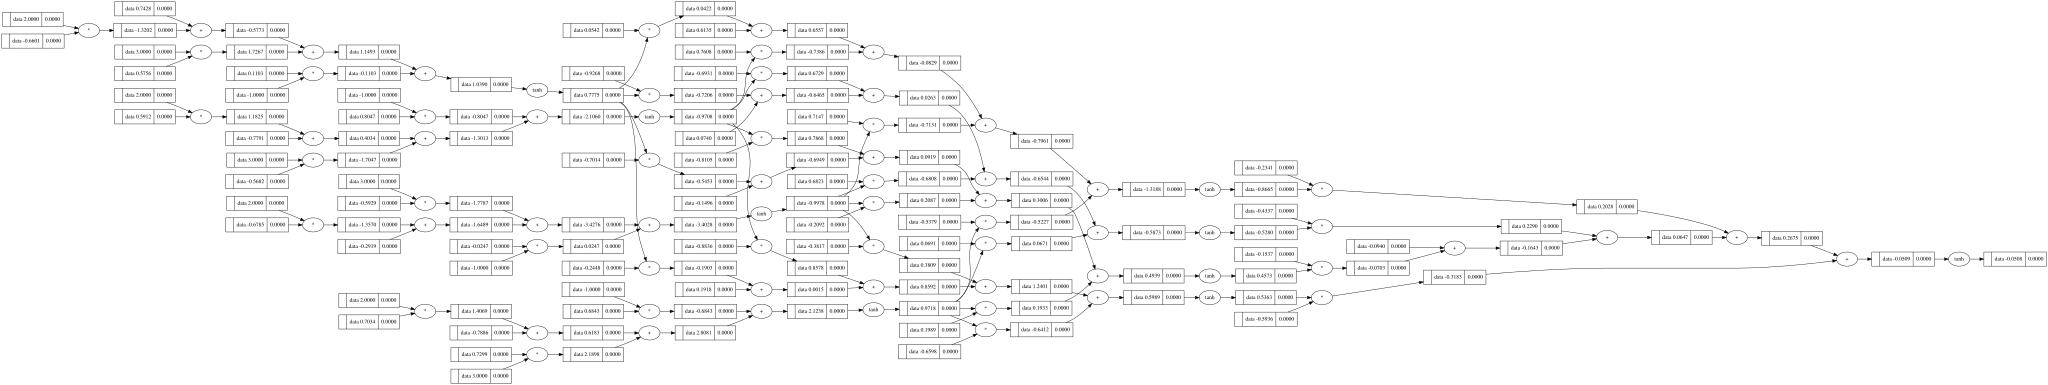

In [13]:
draw_dot(n(x))